In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use('ggplot')
%matplotlib inline

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Fashion_Retail_Sales.csv to Fashion_Retail_Sales.csv


In [3]:
df = pd.read_csv('Fashion_Retail_Sales.csv')

# Display first 5 rows
df.head()

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
0,4018,Handbag,4619.0,05-02-2023,NaN,Credit Card
1,4115,Tunic,2456.0,11-07-2023,2.0,Credit Card
2,4019,Tank Top,2102.0,23-03-2023,4.1,Cash
3,4097,Leggings,3126.0,15-03-2023,3.2,Cash
4,3997,Wallet,3003.0,27-11-2022,4.7,Cash


In [4]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
df.info()

Shape of Dataset: (3400, 6)

Columns:
Index(['Customer Reference ID', 'Item Purchased', 'Purchase Amount (USD)',
       'Date Purchase', 'Review Rating', 'Payment Method'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3400 non-null   int64  
 1   Item Purchased         3400 non-null   object 
 2   Purchase Amount (USD)  2750 non-null   float64
 3   Date Purchase          3400 non-null   object 
 4   Review Rating          3076 non-null   float64
 5   Payment Method         3400 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 159.5+ KB


In [5]:
print(df.isnull().sum())

Customer Reference ID      0
Item Purchased             0
Purchase Amount (USD)    650
Date Purchase              0
Review Rating            324
Payment Method             0
dtype: int64


In [6]:
df.describe()

,Customer Reference ID,Purchase Amount (USD),Review Rating
count,3400.000000,2750.000000,3076.000000
mean,4039.660588,156.709818,2.999057
std,48.122583,419.536669,1.156505
min,3957.000000,10.000000,1.000000
25%,3997.000000,57.000000,2.000000
50%,4040.000000,110.000000,3.000000
75%,4081.000000,155.750000,4.000000
max,4122.000000,4932.000000,5.000000


In [7]:
print("Mean Purchase Amount:",df['Purchase Amount (USD)'].mean())
print("Median Purchase Amount:",df['Purchase Amount (USD)'].median())
print("Standard Deviation:",df['Purchase Amount (USD)'].std())

Mean Purchase Amount: 156.70981818181818
Median Purchase Amount: 110.0
Standard Deviation: 419.5366688715006


In [8]:
print(df['Item Purchased'].value_counts())

Item Purchased
Belt             90
Skirt            88
Shorts           87
Pants            86
T-shirt          82
Tank Top         82
Pajamas          81
Loafers          76
Camisole         76
Hoodie           75
Socks            73
Kimono           73
Wallet           73
Poncho           73
Blouse           73
Handbag          72
Cardigan         72
Onesie           71
Sneakers         71
Vest             71
Backpack         71
Blazer           71
Umbrella         70
Raincoat         69
Hat              68
Trench Coat      68
Sunglasses       67
Coat             67
Swimsuit         66
Scarf            66
Boots            65
Romper           64
Jacket           64
Flannel Shirt    63
Leggings         62
Sweater          62
Overalls         61
Tunic            61
Gloves           59
Polo Shirt       59
Trousers         58
Jeans            58
Slippers         58
Tie              57
Jumpsuit         57
Dress            57
Sandals          54
Bowtie           52
Flip-Flops       51
Sun H

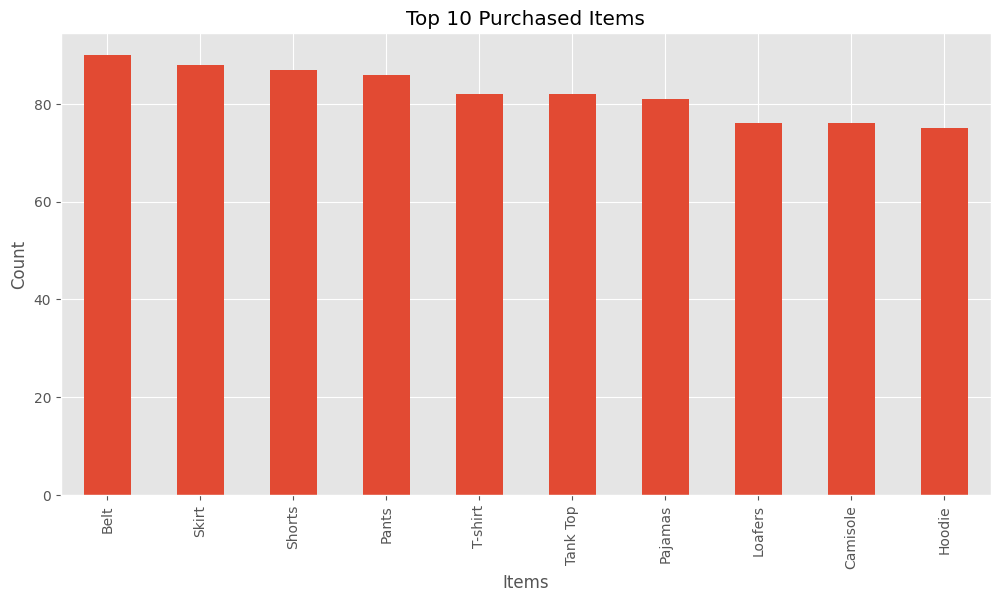

In [9]:
plt.figure(figsize=(12,6))
df['Item Purchased'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Purchased Items')
plt.xlabel('Items')
plt.ylabel('Count')
plt.show()

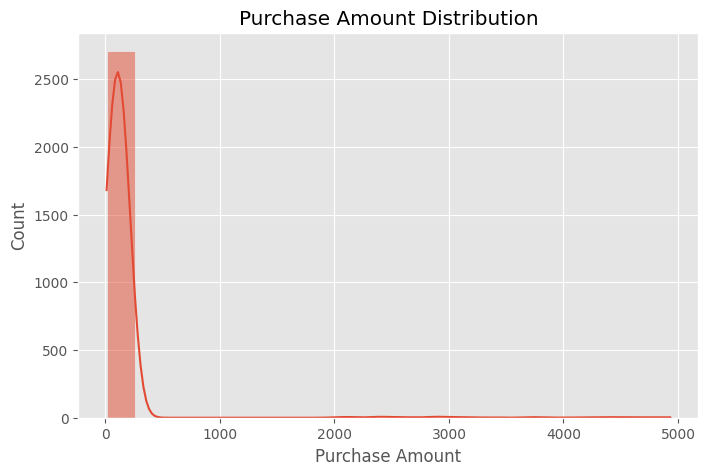

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['Purchase Amount (USD)'],
             bins=20,
             kde=True)

plt.title('Purchase Amount Distribution')
plt.xlabel('Purchase Amount')
plt.show()

In [11]:
payment_counts = df['Payment Method'].value_counts()

print(payment_counts)

Payment Method
Credit Card    1770
Cash           1630
Name: count, dtype: int64


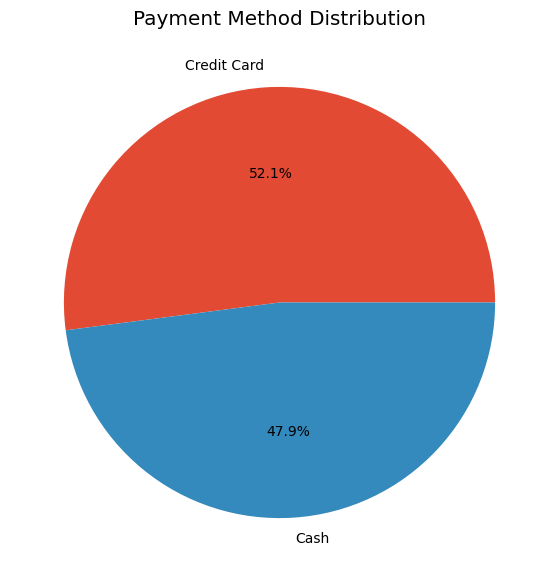

In [12]:
plt.figure(figsize=(7,7))

plt.pie(payment_counts,
        labels=payment_counts.index,
        autopct='%1.1f%%')

plt.title("Payment Method Distribution")
plt.show()

In [13]:
rating = df.groupby('Payment Method')['Review Rating'].mean()

print(rating)

Payment Method
Cash           2.994804
Credit Card    3.003011
Name: Review Rating, dtype: float64


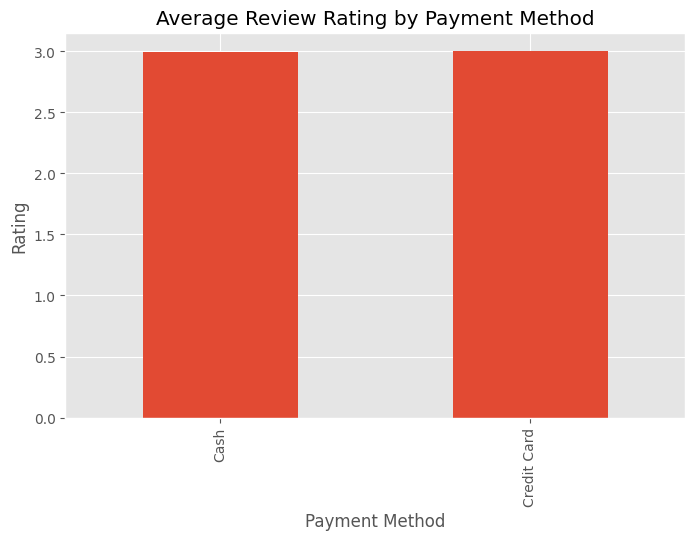

In [14]:
plt.figure(figsize=(8,5))

rating.plot(kind='bar')

plt.title("Average Review Rating by Payment Method")
plt.ylabel("Rating")
plt.show()

In [17]:
df['Date Purchase'] = pd.to_datetime(df['Date Purchase'], format="%d-%m-%Y")

df['Month'] = df['Date Purchase'].dt.month

In [18]:
monthly_sales = df.groupby('Month')['Purchase Amount (USD)'].sum()

print(monthly_sales)

Month
1     29887.0
2     33879.0
3     39380.0
4     40220.0
5     45352.0
6     35542.0
7     33176.0
8     35809.0
9     24492.0
10    31235.0
11    35129.0
12    46851.0
Name: Purchase Amount (USD), dtype: float64


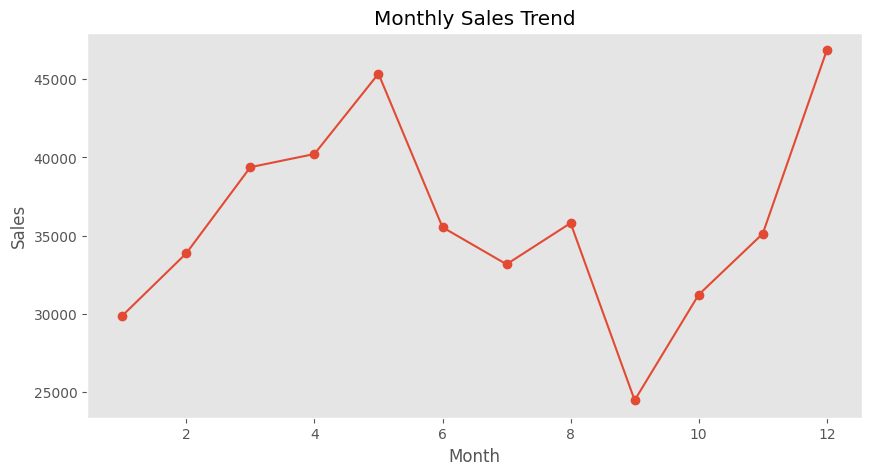

In [19]:
plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid()
plt.show()

In [20]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.head()

,Customer Reference ID,Purchase Amount (USD),Review Rating
0,4018,4619.0,NaN
1,4115,2456.0,2.0
2,4019,2102.0,4.1
3,4097,3126.0,3.2
4,3997,3003.0,4.7


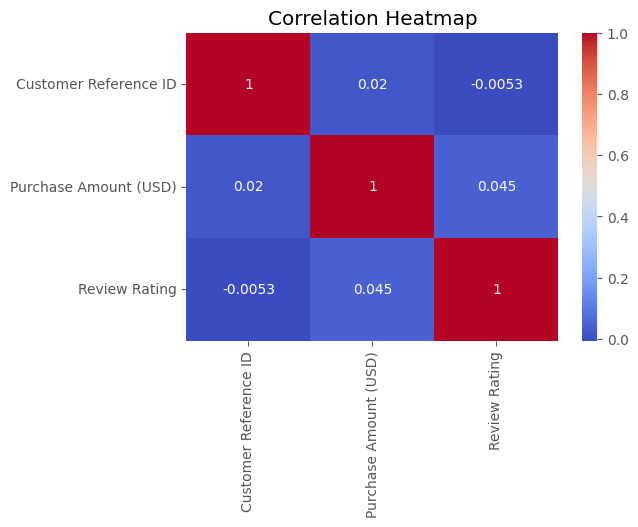

In [21]:
plt.figure(figsize=(6,4))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [22]:
top_products = df.groupby('Item Purchased')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

print(top_products.head(10))

Item Purchased
Tunic         17275.0
Jeans         13068.0
Pajamas       12798.0
Shorts        12702.0
Handbag       12668.0
Gloves        12330.0
Boots         11891.0
Poncho        11422.0
Flip-Flops    11309.0
Slippers      11284.0
Name: Purchase Amount (USD), dtype: float64


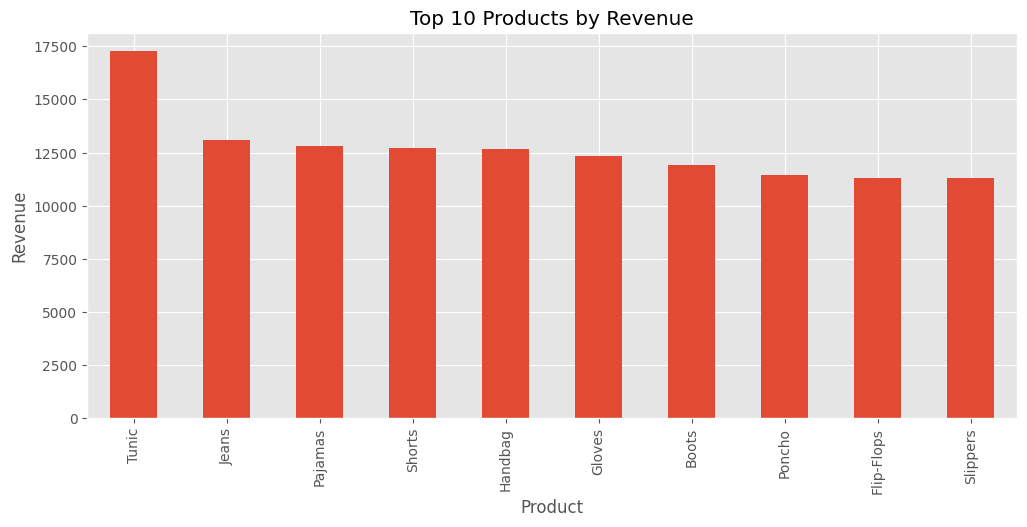

In [23]:
plt.figure(figsize=(12,5))

top_products.head(10).plot(kind='bar')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

In [24]:
print("""
Recommendations:

1. Focus marketing on top-selling products.
2. Promote payment methods preferred by customers.
3. Increase stock of high-revenue products.
4. Monitor monthly sales trends for better planning.
5. Improve customer satisfaction based on review ratings.
""")


Recommendations:

1. Focus marketing on top-selling products.
2. Promote payment methods preferred by customers.
3. Increase stock of high-revenue products.
4. Monitor monthly sales trends for better planning.
5. Improve customer satisfaction based on review ratings.



In [25]:
print("""
Conclusion:

• Data cleaning was performed.
• Descriptive statistics were calculated.
• Product and payment analyses were conducted.
• Monthly sales trends were studied.
• Heatmaps and charts helped visualize patterns.
• Insights obtained can help improve retail business decisions.
""")


Conclusion:

• Data cleaning was performed.
• Descriptive statistics were calculated.
• Product and payment analyses were conducted.
• Monthly sales trends were studied.
• Heatmaps and charts helped visualize patterns.
• Insights obtained can help improve retail business decisions.

